In [1]:
text_list = []
with open('../data/jokes.txt', 'r') as f:
    for line in f:
        text_list.append(str(line))

In [2]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

import numpy as np

In [17]:
tokenizer = Tokenizer(BPE())
tokenizer.decoder = ByteLevelDecoder()
tokenizer.pre_tokenizer = ByteLevel()

trainer = BpeTrainer(
    vocab_size=5000,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)

tokenizer.train_from_iterator(text_list, trainer)

In [18]:
tokenizer.save("bpe_tokenizer.json")

In [19]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("bpe_tokenizer.json")

tokenizer.decode(tokenizer.encode("Тестируем токенизатор").ids)

' Тестируем токенизатор'

# Гистограммы по токенам:

In [20]:
import matplotlib.pyplot as plt

In [21]:
tokens_stat = []
for line in text_list:
    tokens_stat.append(len(tokenizer.encode(line).ids))

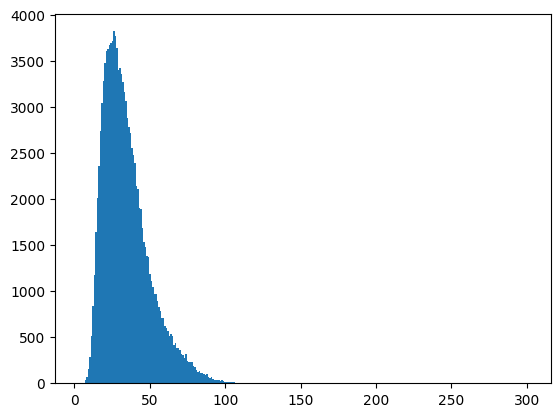

In [23]:
plt.hist(tokens_stat, max(tokens_stat))
plt.show()